In [ ]:
import os
import pandas as pd
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer

# Charger le modèle français de spaCy
nlp = spacy.load("fr_core_news_sm")

# Dossier contenant les 118 fichiers
dossier = "/Users/anastasiiazorych/Desktop/data"

def lemmatiser(texte):
    doc = nlp(texte)
    lemmes = []

    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.is_space
            and token.is_alpha
            and len(token.lemma_) > 2
        ):
            lemmes.append(token.lemma_.lower())

    return " ".join(lemmes)

# Lecture de tous les fichiers .txt
documents = []
noms_fichiers = []

import re

def extraire_numero(nom_fichier):
    match = re.search(r"page_(\d+)", nom_fichier)
    if match:
        return int(match.group(1))
    return 999999

fichiers = [
    fichier for fichier in os.listdir(dossier)
    if fichier.endswith(".txt")
]

fichiers = sorted(fichiers, key=extraire_numero)

for fichier in fichiers:
        chemin = os.path.join(dossier, fichier)

        with open(chemin, "r", encoding="utf-8") as f:
            texte = f.read()

        texte_lemme = lemmatiser(texte)

        documents.append(texte_lemme)
        noms_fichiers.append(fichier)

print("Nombre de documents chargés :", len(documents))

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)
mots = vectorizer.get_feature_names_out()

resultats_top10 = []

for i, nom_fichier in enumerate(noms_fichiers):
    scores = tfidf_matrix[i].toarray().flatten()

    # Indices des 10 meilleurs scores
    top_indices = scores.argsort()[::-1][:10]

    for rang, index_mot in enumerate(top_indices, start=1):
        terme = mots[index_mot]
        score = scores[index_mot]

        resultats_top10.append({
            "Candidature": nom_fichier,
            "Rang": rang,
            "Terme": terme,
            "Score TF-IDF": round(score, 4)
        })

# Transformation en DataFrame
df_top10 = pd.DataFrame(resultats_top10)

print(df_top10)

# Sauvegarde dans un fichier CSV lisible
df_top10.to_csv(
    "/Users/anastasiiazorych/Desktop/top10_tfidf_par_candidature2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tableau top 10 sauvegardé sur le Bureau.")

Nombre de documents chargés : 122
       Candidature  Rang            Terme  Score TF-IDF
0     page_001.txt     1  bioinformatique        0.3787
1     page_001.txt     2             inem        0.2949
2     page_001.txt     3           donnée        0.2549
3     page_001.txt     4          analyse        0.2298
4     page_001.txt     5             mnhn        0.1877
...            ...   ...              ...           ...
1215  page_122.txt     6  caractérisation        0.1853
1216  page_122.txt     7     électronique        0.1803
1217  page_122.txt     8        géochimie        0.1786
1218  page_122.txt     9         grenoble        0.1725
1219  page_122.txt    10       plateforme        0.1703

[1220 rows x 4 columns]
Tableau top 10 sauvegardé sur le Bureau.


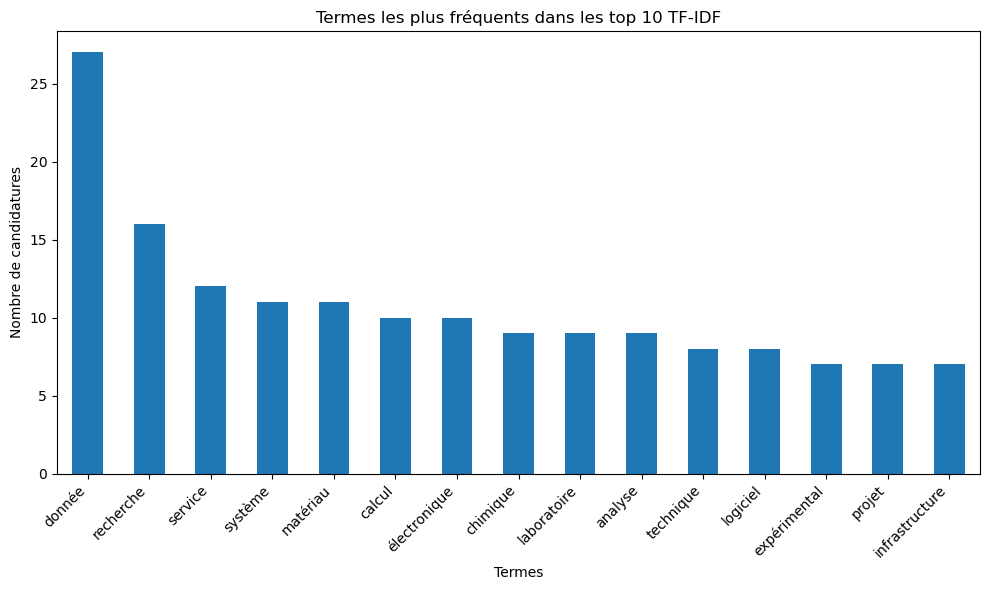

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/anastasiiazorych/Desktop/top10_tfidf_par_candidature.csv")

top_termes = (
    df.groupby("Terme")["Candidature"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
top_termes.plot(kind="bar")
plt.xlabel("Termes")
plt.ylabel("Nombre de candidatures")
plt.title("Termes les plus fréquents dans les top 10 TF-IDF")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("/Users/anastasiiazorych/Desktop/top10_tfidf_par_candidature.csv")

resume_termes = (
    df.groupby("Terme")
    .agg(
        Nombre_de_candidatures=("Candidature", "nunique"),
        Score_moyen=("Score TF-IDF", "mean")
    )
    .reset_index()
    .sort_values(by="Nombre_de_candidatures", ascending=False)
)

print(resume_termes.head(20))

resume_termes.to_csv(
    "/Users/anastasiiazorych/Desktop/resume_termes_frequents.csv",
    index=False,
    encoding="utf-8-sig"
)

               Terme  Nombre_de_candidatures  Score_moyen
194           donnée                      27     0.220385
596        recherche                      16     0.145800
640          service                      12     0.175967
685          système                      11     0.182282
420         matériau                      11     0.257645
99            calcul                      10     0.260840
777     électronique                      10     0.236310
125         chimique                       9     0.155867
370      laboratoire                       9     0.139689
22           analyse                       9     0.165056
695        technique                       8     0.154800
392         logiciel                       8     0.183688
234     expérimental                       7     0.181386
567           projet                       7     0.148914
325   infrastructure                       7     0.161057
509            paris                       6     0.152950
104  caractéri

In [ ]:
import pandas as pd
import re


fichier_entree = "/Users/anastasiiazorych/Desktop/top10_tfidf_par_candidature.csv"

df = pd.read_csv(fichier_entree)

# Nettoyage des colonnes
df["Terme"] = df["Terme"].astype(str).str.lower().str.strip()
df["Score TF-IDF"] = df["Score TF-IDF"].astype(str).str.replace(",", ".").astype(float)
df["Rang"] = df["Rang"].astype(int)


domaines = {
    "Sciences du vivant / Bioinformatique": [
        "bioinformatique", "biologie", "biologique", "génome", "génomique",
        "séquençage", "adn", "arn", "rna", "cellule", "cellulaire",
        "noyau", "protéine", "protéomique", "métabolomique",
        "moléculaire", "chromatine", "transcriptome", "clinique",
        "maladie", "santé", "immunologie", "virologie", "bactériologie",
        "écologie", "biodiversité", "vivant"
    ],

    "Informatique / Science des données": [
        "donnée", "analyse", "statistique", "informatique", "logiciel",
        "algorithme", "python", "pipeline", "code", "calcul",
        "modèle", "modélisation", "apprentissage", "machine",
        "intelligence", "ia", "base", "traitement", "numérique",
        "information", "web", "application", "automatisation"
    ],

    "Physique / Modélisation / Simulation": [
        "physique", "simulation", "dynamique", "modèle", "modélisation",
        "quantique", "thermique", "mécanique", "énergie", "nucléaire",
        "particule", "rayonnement", "optique", "photonique",
        "magnétique", "résonance"
    ],

    "Chimie / Matériaux / Procédés": [
        "chimie", "chimique", "matériau", "matériaux", "molécule",
        "polymère", "surface", "synthèse", "caractérisation",
        "spectroscopie", "dépôt", "procédé", "fabrication",
        "solide", "gaz", "ion", "matrice", "microfluidique"
    ],

    "Instrumentation / Mesure / Imagerie": [
        "instrument", "instrumentation", "mesure", "capteur",
        "électronique", "optique", "laser", "détecteur",
        "imagerie", "image", "microscope", "microscopie",
        "acquisition", "signal", "sonde", "appareil",
        "équipement", "dispositif", "maintenance"
    ],

    "Sciences de la Terre / Environnement": [
        "environnement", "terre", "climat", "océan", "mer",
        "atmosphère", "écologie", "biodiversité", "géologie",
        "géographique", "terrain", "observation", "eau",
        "sol", "écosystème"
    ],

    "Mathématiques / Statistiques": [
        "mathématique", "mathématiques", "statistique", "probabilité",
        "modèle", "modélisation", "optimisation", "équation",
        "algorithme", "calcul", "simulation"
    ],

    "Sciences humaines et sociales / Patrimoine": [
        "archéologie", "archéologique", "patrimoine", "culture",
        "politique", "sociologie", "histoire", "historique",
        "terrain", "vestige", "antique", "humain",
        "cognitif", "langage", "documentation"
    ],

    "Systèmes / Réseaux / Infrastructure": [
        "système", "réseau", "infrastructure", "stockage",
        "sécurité", "serveur", "cluster", "cloud", "linux",
        "unix", "administrateur", "hpc", "base", "architecture"
    ]
}


def classer_candidature(groupe):
    scores_domaines = {domaine: 0 for domaine in domaines}
    termes_associes = {domaine: [] for domaine in domaines}

    for _, ligne in groupe.iterrows():
        terme = ligne["Terme"]
        score = ligne["Score TF-IDF"]

        for domaine, mots_cles in domaines.items():
            for mot_cle in mots_cles:
                if terme == mot_cle or mot_cle in terme or terme in mot_cle:
                    scores_domaines[domaine] += score
                    termes_associes[domaine].append(terme)
                    break

    domaine_attribue = max(scores_domaines, key=scores_domaines.get)
    score_domaine = scores_domaines[domaine_attribue]
    score_total = sum(scores_domaines.values())

    if score_total == 0:
        confiance = 0
        domaine_attribue = "Non déterminé"
        termes = ""
    else:
        confiance = score_domaine / score_total
        termes = ", ".join(sorted(set(termes_associes[domaine_attribue])))

    return pd.Series({
        "Domaine attribué": domaine_attribue,
        "Score du domaine": round(score_domaine, 4),
        "Confiance": round(confiance, 4),
        "Termes utilisés": termes
    })


resultats = (
    df.groupby("Candidature")
    .apply(classer_candidature)
    .reset_index()
)


def extraire_numero(nom):
    match = re.search(r"page_(\d+)", nom)
    if match:
        return int(match.group(1))
    return 999999

resultats["Numéro"] = resultats["Candidature"].apply(extraire_numero)
resultats = resultats.sort_values("Numéro")

# Réorganiser les colonnes
resultats = resultats[
    [
        "Numéro",
        "Candidature",
        "Domaine attribué",
        "Score du domaine",
        "Confiance",
        "Termes utilisés"
    ]
]


fichier_sortie = "/Users/anastasiiazorych/Desktop/candidatures_domaines_scientifiques.csv"

resultats.to_csv(
    fichier_sortie,
    index=False,
    encoding="utf-8-sig"
)

print(resultats)
print("\nFichier sauvegardé ici :")
print(fichier_sortie)


resume_domaines = (
    resultats["Domaine attribué"]
    .value_counts()
    .reset_index()
)

resume_domaines.columns = ["Domaine scientifique", "Nombre de candidatures"]

print("\nRésumé par domaine :")
print(resume_domaines)

resume_domaines.to_csv(
    "/Users/anastasiiazorych/Desktop/resume_domaines_scientifiques.csv",
    index=False,
    encoding="utf-8-sig"
)

     Numéro   Candidature                      Domaine attribué  \
0         1  page_001.txt    Informatique / Science des données   
1         2  page_002.txt  Sciences du vivant / Bioinformatique   
2         3  page_003.txt   Instrumentation / Mesure / Imagerie   
3         4  page_004.txt  Sciences du vivant / Bioinformatique   
4         5  page_005.txt  Sciences du vivant / Bioinformatique   
..      ...           ...                                   ...   
117     118  page_118.txt         Chimie / Matériaux / Procédés   
118     119  page_119.txt         Chimie / Matériaux / Procédés   
119     120  page_120.txt         Chimie / Matériaux / Procédés   
120     121  page_121.txt         Chimie / Matériaux / Procédés   
121     122  page_122.txt   Instrumentation / Mesure / Imagerie   

     Score du domaine  Confiance  \
0              1.0865     0.6339   
1              0.7576     0.4958   
2              0.5323     0.5968   
3              0.8799     0.8782   
4              

/var/folders/qz/xfwf9pdj2y19s_dtwrmw1r540000gn/T/ipykernel_61504/2669338300.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classer_candidature)


In [ ]:
import pandas as pd


fichier_entree = "/Users/anastasiiazorych/Desktop/candidatures_domaines_scientifiques.csv"

df = pd.read_csv(fichier_entree)

# Vérification / nettoyage
df["Confiance"] = df["Confiance"].astype(str).str.replace(",", ".").astype(float)


def domaines_par_seuil(df, seuil):
    df_filtre = df[df["Confiance"] >= seuil]

    resume = (
        df_filtre["Domaine attribué"]
        .value_counts()
        .reset_index()
    )

    resume.columns = ["Domaine scientifique", "Nombre de candidatures"]

    total = len(df_filtre)

    if total > 0:
        resume["Pourcentage"] = round(
            resume["Nombre de candidatures"] / total * 100, 2
        )
    else:
        resume["Pourcentage"] = 0

    resume["Seuil de confiance"] = seuil
    resume["Nombre total de candidatures retenues"] = total

    return resume


seuils = [0.8, 0.5, 0.2]

resultats = []

for seuil in seuils:
    resume = domaines_par_seuil(df, seuil)
    resultats.append(resume)

df_resultats = pd.concat(resultats, ignore_index=True)


for seuil in seuils:
    print("\n" + "=" * 60)
    print(f"Domaines les plus représentés pour Confiance >= {seuil}")
    print("=" * 60)

    affichage = df_resultats[df_resultats["Seuil de confiance"] == seuil]
    print(affichage)


fichier_sortie = "/Users/anastasiiazorych/Desktop/domaines_par_seuil_confiance.csv"

df_resultats.to_csv(
    fichier_sortie,
    index=False,
    encoding="utf-8-sig"
)

print("\nFichier sauvegardé ici :")
print(fichier_sortie)


Domaines les plus représentés pour Confiance >= 0.8
                         Domaine scientifique  Nombre de candidatures  \
0               Chimie / Matériaux / Procédés                       8   
1        Sciences du vivant / Bioinformatique                       2   
2  Sciences humaines et sociales / Patrimoine                       2   
3          Informatique / Science des données                       2   
4         Instrumentation / Mesure / Imagerie                       1   

   Pourcentage  Seuil de confiance  Nombre total de candidatures retenues  
0        53.33                 0.8                                     15  
1        13.33                 0.8                                     15  
2        13.33                 0.8                                     15  
3        13.33                 0.8                                     15  
4         6.67                 0.8                                     15  

Domaines les plus représentés pour Confiance >= 0.5